# Clase de Matplotlib

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import random
import math
import datetime

%matplotlib inline
random.seed(0)
print("Versión de matplotlib:", plt.matplotlib.__version__)

Versión de matplotlib: 3.11.0


## 1. De `plt.plot()` a `fig, ax = plt.subplots()`


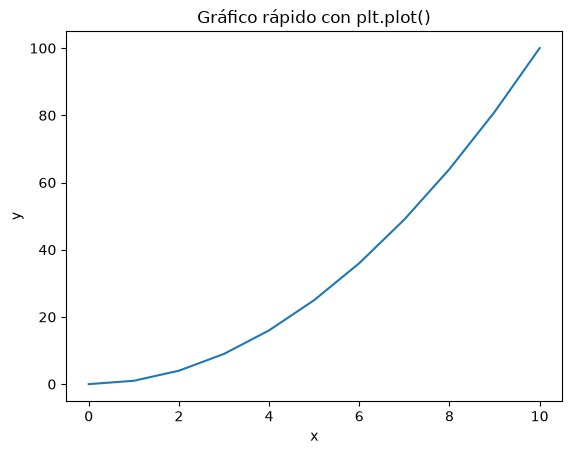

In [3]:
x = list(range(11))          # 0, 1, 2, ..., 10
y = [v ** 2 for v in x]      # cuadrados

plt.plot(x, y)
plt.title("Gráfico rápido con plt.plot()")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Aquí `pyplot` mantiene "por detrás" una figura y un axes actuales, y cada función (`plt.plot`, `plt.title`, `plt.xlabel`...) actúa sobre ellos implícitamente. Es cómodo, pero tiene un problema: **cuando necesitamos más de un gráfico**, o volver a un gráfico anterior para modificarlo, ya no queda claro sobre cuál estamos actuando.

Otra forma es pedir explícitamente `fig` y `ax`, y llamar a los métodos **sobre `ax`** (`ax.plot`, `ax.set_title`, `ax.set_xlabel`...).

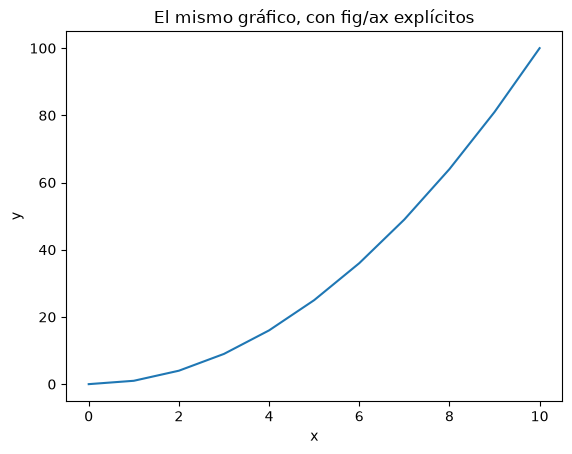

In [4]:
fig, ax = plt.subplots()

ax.plot(x, y)
ax.set_title("El mismo gráfico, con fig/ax explícitos")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show() # esta línea no es necesaria en júpiter, pero sí si corremos un script de python.

La diferencia se nota apenas necesitamos **más de un gráfico**. Con `plt.plot()` solo trabajás con el eje actual, de la otra manera podemos especificar el eje a usar:

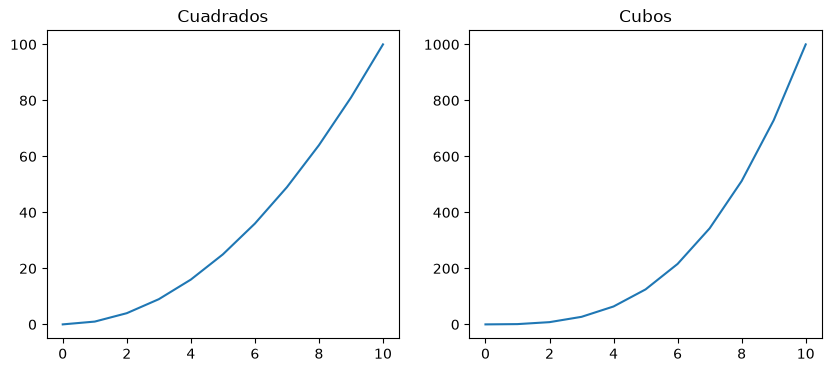

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))  # dos Axes, uno al lado del otro

ax1.plot(x, y)
ax1.set_title("Cuadrados")

y_cubos = [v ** 3 for v in x]
ax2.plot(x, y_cubos)
ax2.set_title("Cubos")


plt.show()

**En resumen:** `plt.plot()` sirve para pruebas rápidas de un solo gráfico. Si quisiéramos acceder al eje del gráfico lo podemos hacer con el método `plt.gca()`.

Poro si el gráfico se vuelve más complejo (varios subplots, ejes secundarios, guardar la figura, modificar algo puntual) conviene empezar definiendo la figura como `fig, ax = plt.subplots()`.

Otro detalle: en ninguno de estos gráficos indicamos un color, matplotlib eligió uno automáticamente. Veamos de dónde sale ese color y qué otras formas hay de elegirlo nosotros mismos.

## 2. Formas de especificar colores

Cuando no indicamos ningún color, matplotlib va rotando automáticamente por un **ciclo de colores** por defecto (10 colores, conocido como paleta `tab10`). Por eso cada `ax.plot` nuevo dentro del mismo `ax` sale de un color distinto sin que hagamos nada.

Pero también podemos elegir el color nosotros, de varias formas:

- **Nombres CSS**: `"red"`, `"blue"`, `"green"`, `"black"`... (los básicos de HTML/CSS)
- **Paleta Tableau**: `"tab:blue"`, `"tab:orange"`, `"tab:green"`... son los mismos 10 colores del ciclo por defecto, pero fijos (no importa el orden en que los uses)
- **Índice del ciclo actual**: `"C0"`, `"C1"`, ..., `"C9"` — apunta al color que le toca a esa posición en el ciclo activo. Por defecto `"C0"` es igual a `"tab:blue"`, `"C1"` igual a `"tab:orange"`, etc., pero si cambiás el ciclo (por ejemplo con un estilo distinto) `"C1"` se actualiza solo, mientras que `"tab:orange"` queda fijo
- **Código hexadecimal**: `"#3498db"`, igual que en diseño web/CSS
- **RGB (o RGBA) en tupla**: `(0.2, 0.4, 0.6)` con valores entre 0 y 1, opcionalmente con un cuarto valor de transparencia `(0.2, 0.4, 0.6, 0.5)`
- **Escala de grises**: un string con un número entre `"0"` (negro) y `"1"` (blanco), por ejemplo `"0.5"`

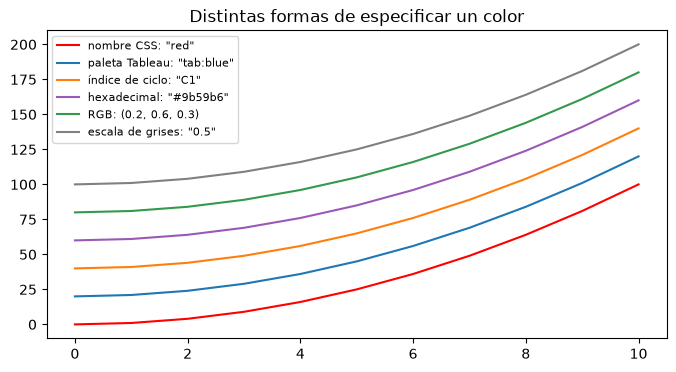

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, [v + 0 for v in y], color="red", label='nombre CSS: "red"')
ax.plot(x, [v + 20 for v in y], color="tab:blue", label='paleta Tableau: "tab:blue"')
ax.plot(x, [v + 40 for v in y], color="C1", label='índice de ciclo: "C1"')
ax.plot(x, [v + 60 for v in y], color="#9b59b6", label='hexadecimal: "#9b59b6"')
ax.plot(x, [v + 80 for v in y], color=(0.2, 0.6, 0.3), label="RGB: (0.2, 0.6, 0.3)")
ax.plot(x, [v + 100 for v in y], color="0.5", label='escala de grises: "0.5"')

ax.set_title("Distintas formas de especificar un color")
ax.legend(loc="upper left", fontsize=8)
plt.show()

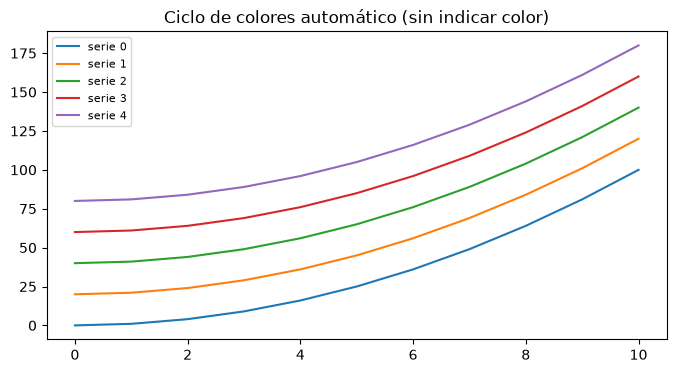

In [7]:
# Sin especificar color: matplotlib rota automáticamente por el ciclo (tab10 por defecto)
fig, ax = plt.subplots(figsize=(8, 4))

for i in range(5):
    ax.plot(x, [v + i * 20 for v in y], label=f"serie {i}")

ax.set_title("Ciclo de colores automático (sin indicar color)")
ax.legend(loc="upper left", fontsize=8)
plt.show()

## 3. Estilos predefinidos

Matplotlib trae "temas" listos para cambiar la apariencia general (colores, grillas, fuentes) sin configurar todo a mano. Se aplican con `plt.style.use("nombre_estilo")` **antes** de crear la figura.

In [ ]:
print(plt.style.available[:10])  # algunos estilos disponibles

In [ ]:
x2 = [i / 10 for i in range(101)]        # 0.0, 0.1, ..., 10.0
y1 = [math.sin(v) for v in x2]
y2 = [math.cos(v) for v in x2]

with plt.style.context("seaborn-v0_8-darkgrid"):  # aplica el estilo solo dentro del bloque 'with'
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(x2, y1, label="seno")
    ax.plot(x2, y2, label="coseno")
    ax.legend()
    ax.set_title("Estilo: seaborn-v0_8-darkgrid")
    plt.show()

> `plt.style.use("nombre")` cambia el estilo para *todos* los gráficos siguientes en la sesión. Usar `with plt.style.context("nombre"):` lo aplica solo a ese bloque: más prolijo.

Al cambiar de estilo, el color por defecto de la primera línea también puede cambiar: el ciclo de colores es parte del estilo.

## 4. Anotaciones y texto

Para señalar un punto puntual en el gráfico (por ejemplo, un máximo o un evento importante) usamos `ax.annotate()`. Para agregar texto libre en cualquier posición, usamos `ax.text()`.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x2, y1)

# Encontramos el punto máximo "a mano"
y_max = max(y1)
idx_max = y1.index(y_max)
x_max = x2[idx_max]

# annotate: pone una flecha desde xytext hasta xy
ax.annotate(
    "máximo",
    xy=(x_max, y_max),                  # punto que señalamos
    xytext=(x_max + 1.5, y_max - 0.3),  # dónde va el texto
    arrowprops=dict(arrowstyle="->"),
)

# text: solo pone texto en una posición, sin flecha
ax.text(6, -0.8, "zona de valores negativos", fontsize=9)

ax.set_title("Anotaciones sobre un gráfico")
plt.show()

## 5. Eje secundario (`twinx`)

Cuando queremos comparar dos series con escalas muy distintas (por ejemplo, temperatura en °C y precipitación en mm) en el mismo gráfico, usamos un segundo eje Y con `ax.twinx()`.

In [ ]:
dias = list(range(1, 11))
temperatura = [20, 22, 21, 24, 26, 25, 23, 22, 21, 20]
precipitacion = [0, 5, 12, 0, 0, 2, 8, 15, 3, 0]

fig, ax1 = plt.subplots(figsize=(8, 4))

# Eje izquierdo: temperatura
linea_temp, = ax1.plot(dias, temperatura, marker="o", label="Temperatura")
ax1.set_xlabel("Día")
ax1.set_ylabel("Temperatura (°C)")

# Eje derecho: precipitación
ax2 = ax1.twinx()
barras_precip = ax2.bar(dias, precipitacion, alpha=0.4, label="Precipitación")
ax2.set_ylabel("Precipitación (mm)")

ax1.set_title("Temperatura y precipitación (dos escalas distintas)")
ax1.legend(handles=[linea_temp, barras_precip], loc="upper left")
plt.show()

## 6. Histogramas y boxplots

- **Histograma** (`ax.hist`): muestra cómo se distribuyen los valores de una variable, agrupándolos en "bins" (intervalos).
- **Boxplot** (`ax.boxplot`): resume una distribución con mediana, cuartiles y valores atípicos (outliers), útil para comparar varios grupos.

In [ ]:
# Simulamos 1000 alturas usando random.gauss (distribución normal)
datos = [random.gauss(170, 10) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(datos, bins=30, edgecolor="white")
ax.set_title("Histograma de alturas simuladas")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Frecuencia")
plt.show()

In [ ]:
grupo_a = [random.gauss(50, 5) for _ in range(200)]
grupo_b = [random.gauss(55, 8) for _ in range(200)]
grupo_c = [random.gauss(45, 3) for _ in range(200)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([grupo_a, grupo_b, grupo_c], labels=["Grupo A", "Grupo B", "Grupo C"])
ax.set_title("Comparación de distribuciones (boxplot)")
ax.grid(True, axis="y", alpha=0.4)
plt.show()

## 7. Barras agrupadas y apiladas

Con `ax.bar` podemos ir más allá de una sola serie: comparar varias categorías **lado a lado** (agrupadas) o **una encima de otra** (apiladas).

In [ ]:
categorias = ["Ene", "Feb", "Mar", "Abr"]
ventas_2024 = [10, 15, 12, 18]
ventas_2025 = [13, 14, 16, 20]

x_pos = list(range(len(categorias)))   # posiciones 0,1,2,3
ancho = 0.35                           # ancho de cada barra
x_izq = [p - ancho / 2 for p in x_pos]
x_der = [p + ancho / 2 for p in x_pos]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_izq, ventas_2024, width=ancho, label="2024")
ax.bar(x_der, ventas_2025, width=ancho, label="2025")

ax.set_xticks(x_pos)
ax.set_xticklabels(categorias)
ax.set_title("Barras agrupadas: ventas por mes")
ax.legend()
plt.show()

In [ ]:
# Barras apiladas: usamos 'bottom' para apilar una serie sobre otra
producto_a = [5, 7, 6, 9]
producto_b = [3, 4, 5, 6]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(categorias, producto_a, label="Producto A")
ax.bar(categorias, producto_b, bottom=producto_a, label="Producto B")

ax.set_title("Barras apiladas: ventas por producto")
ax.legend()
plt.show()

## 8. Áreas rellenas (`fill_between`)

Sirve para resaltar una región entre dos curvas, o mostrar un rango de incertidumbre alrededor de una línea (por ejemplo, una banda de error).

In [ ]:
error = 0.2
y_inf = [v - error for v in y1]
y_sup = [v + error for v in y1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x2, y1, label="seno")
ax.fill_between(x2, y_inf, y_sup, alpha=0.3, label="margen de error")

ax.set_title("Línea con banda de error (fill_between)")
ax.legend()
plt.show()

## 9. Layouts irregulares con `GridSpec`

`plt.subplots(filas, columnas)` sirve para grillas uniformes. Cuando necesitamos que un gráfico ocupe **más espacio** que otro (por ejemplo, uno grande arriba y dos chicos abajo), usamos `GridSpec`.

In [ ]:
fig = plt.figure(figsize=(9, 6))
gs = GridSpec(2, 2, figure=fig)  # grilla lógica de 2 filas x 2 columnas

ax1 = fig.add_subplot(gs[0, :])   # primera fila completa (ambas columnas)
ax2 = fig.add_subplot(gs[1, 0])   # segunda fila, columna izquierda
ax3 = fig.add_subplot(gs[1, 1])   # segunda fila, columna derecha

ax1.plot(x2, y1)
ax1.set_title("Gráfico grande (ocupa toda la fila)")

puntos_x = [random.random() * 10 for _ in range(30)]
puntos_y = [random.random() * 10 for _ in range(30)]
ax2.scatter(puntos_x, puntos_y)
ax2.set_title("Scatter")

datos_hist = [random.gauss(0, 1) for _ in range(300)]
ax3.hist(datos_hist, bins=20)
ax3.set_title("Histograma")

plt.tight_layout()
plt.show()

## 10. Fechas en el eje X

Cuando trabajamos con series temporales, matplotlib puede manejar objetos `datetime` directamente en el eje X, y formatear las etiquetas con `mdates`.

In [ ]:
fechas = [datetime.date(2025, 1, 1) + datetime.timedelta(days=7 * i) for i in range(12)]

# "Caminata aleatoria": cada valor es el anterior + un cambio al azar
valores = [100]
for _ in range(11):
    valores.append(valores[-1] + random.gauss(0, 3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fechas, valores, marker="o")

# Formateamos las fechas mostradas en el eje X
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
fig.autofmt_xdate(rotation=45)  # rota las etiquetas para que no se superpongan

ax.set_title("Serie temporal semanal")
ax.grid(True, alpha=0.4)
plt.show()

## 11. Guardar figuras (`savefig`)

Para exportar un gráfico a un archivo (PNG, PDF, SVG, etc.), usamos `fig.savefig()`. Conviene usar `dpi` alto para buena resolución y `bbox_inches="tight"` para que no corte etiquetas.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x2, y1)
ax.set_title("Gráfico para exportar")

fig.savefig("mi_grafico.png", dpi=150, bbox_inches="tight")
print("Guardado como mi_grafico.png")

# También se puede exportar a PDF o SVG cambiando la extensión:
# fig.savefig("mi_grafico.pdf", bbox_inches="tight")
# fig.savefig("mi_grafico.svg", bbox_inches="tight")

## 12. Repaso

| Concepto | Cómo se usa |
|---|---|
| `plt.plot()` vs `fig, ax` | rápido y ambiguo vs explícito y escalable |
| Colores | nombre CSS, `"tab:..."`, `"C0"`-`"C9"`, hex, RGB(A), escala de grises |
| Estilos | `plt.style.use("nombre")` o `with plt.style.context("nombre"):` |
| Anotaciones | `ax.annotate("texto", xy=..., xytext=..., arrowprops=...)` |
| Texto libre | `ax.text(x, y, "texto")` |
| Eje secundario | `ax2 = ax1.twinx()` |
| Histograma | `ax.hist(datos, bins=...)` |
| Boxplot | `ax.boxplot([grupo1, grupo2, ...])` |
| Barras agrupadas | `ax.bar(x_izq, ...)` + `ax.bar(x_der, ...)` |
| Barras apiladas | `ax.bar(..., bottom=serie_anterior)` |
| Área rellena | `ax.fill_between(x, y_inf, y_sup)` |
| Layout irregular | `GridSpec` + `fig.add_subplot(gs[fila, columna])` |
| Fechas en eje X | `mdates.DateFormatter`, `fig.autofmt_xdate()` |
| Guardar figura | `fig.savefig("archivo.png", dpi=150, bbox_inches="tight")` |

## 13. Ejercicio

1. Copiar los datos de la tabla https://www.wunderground.com/dashboard/pws/IBARIL12/table/2026-07-31/2026-07-31/monthly en un archivo
2. Parsear los datos a una matriz
3. Obtener de la matriz la lista de fechas y temperaturas promedio, máx y mín.
4. Graficar las 3 temperaturas
5. Graficar la temperatura promedio y rellenar el área entre las temperaturas máxima y mínima
6. Volver a graficar usando el estilo *seaborn* del ejemplo.